In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.options.mode.chained_assignment = None 

import h5py as h5 
from astropy import units as u
from astropy import constants as c
from astropy.cosmology import Planck18
from scipy.interpolate import interp1d

import os
import scipy
from collections import Counter
from collections import defaultdict
import gc

pd.options.display.max_columns = None

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "16",
    "xtick.labelsize": "16",
    "ytick.labelsize": "16",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images

from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))


In [ ]:
# pop_names = ['notides_bavera', 'realistic_bavera', 'perfect_bavera']
pop_names = ['realistic', 'realistic_bavera']



pop_labels = {'notides': 'LEGACY',
              'realistic': 'KAPIL26',
              'realistic_bavera': 'Bavera et al. (2021) Fit',
              'perfect': 'PERFECT'}

pop_colors = {'notides': colorPalette['red'],
              'realistic': colorPalette['blue'],
              'realistic_bavera': colorPalette['violet'],
              'perfect': colorPalette['green']}

pop_cmaps = {'notides': 'Reds',
              'realistic': 'Blues',
              'realistic_bavera': 'Oranges',
              'perfect': 'Greens'}

dco_types = ['BBH', 'BHNS', 'BNS']
dco_st = [28, 27, 26]
mt_labels = [
    "No MT", "Stable MT 1→2", "Stable MT 2→1", 
    "CE_Primary", "CE_Secondary", "CE_Both", "MT to Merger"
]
branching_labels = {1: 'Primary', 2: 'Secondary', 3: 'Both', 4: 'MT_to_Merger'}

plot_path = 'pop_plots/'

data_path = 'data_files/'

if not os.path.exists(data_path):
   os.makedirs(data_path)

In [5]:
pop_spin_dfs = {}
for pop_name in pop_names:
    pop_spin_dfs[pop_name] = pd.read_csv(data_path + pop_name+'_spin_df.csv') 


# Figure 14

KAPIL26
Maximally spinning BBH primaries: 32 / 42592 (0.08%)
Maximally spinning BBH secondaries: 15887 / 42592 (37.30%)

Bavera et al. (2021) Fit
Maximally spinning BBH primaries: 16 / 42592 (0.04%)
Maximally spinning BBH secondaries: 2560 / 42592 (6.01%)



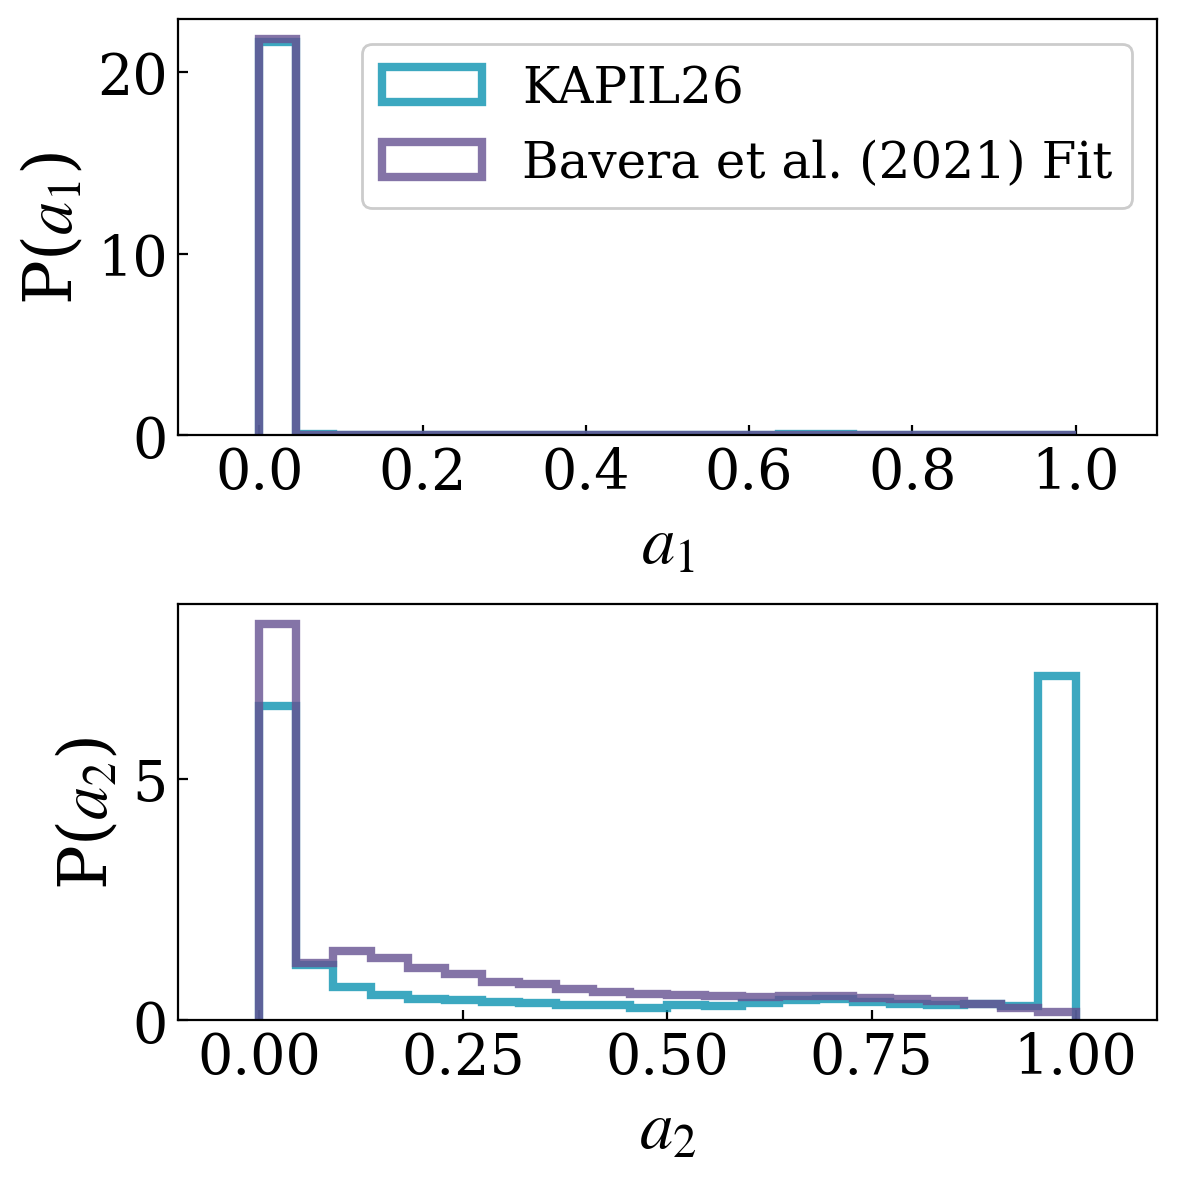

In [ ]:
use_orbital_period = False

fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(6,6), sharey=False)

dco_type = 'BBH'

for pop_name in pop_names:
    pop_spin_df = pop_spin_dfs[pop_name]
    pop_spin_df = pop_spin_df[(pop_spin_df[dco_type]) & (pop_spin_df["Merges_Hubble_Time"])]

    m1, m2 = pop_spin_df["Mass@DCO(1)"], pop_spin_df["Mass@DCO(2)"]    
    a1, a2 = pop_spin_df["a1"], pop_spin_df["a2"]

    if use_orbital_period:
        a1, a2 = pop_spin_df["a1_orb"], pop_spin_df["a2_orb"]
    
    if pop_name == 'notides' or 'bavera' in pop_name:
        a1, a2 = pop_spin_df["a1_orb"], pop_spin_df["a2_orb"]
        

    #  # Label by primary and secondary of DCO
    # invert_mask = m1 < m2
    # a1_relabeled, a2_relabeled = a1.copy(), a2.copy()
    # a1_relabeled[invert_mask], a2_relabeled[invert_mask] = a2[invert_mask], a1[invert_mask]
    # a1, a2 = a1_relabeled, a2_relabeled

    bins = np.linspace(0, 1.0, 23)
    axes[0].hist(a1, bins=bins, density=True, alpha=0.8, histtype='step', lw=3, ls='-', label=pop_labels[pop_name], color=pop_colors[pop_name])
    axes[1].hist(a2, bins=bins, density=True, alpha=0.8, histtype='step', lw=3, ls='-', label=pop_labels[pop_name], color=pop_colors[pop_name])

    
    if dco_type == 'BBH':
        print(pop_labels[pop_name])
        print(f"Maximally spinning BBH primaries: {np.sum(a1>0.8)} / {len(a1)} ({100 * np.sum(a1>0.8)/len(a1):.2f}%)")
        print(f"Maximally spinning BBH secondaries: {np.sum(a2>0.8)} / {len(a2)} ({100 * np.sum(a2>0.8)/len(a2):.2f}%)")
        print()

# axes[0].set_title(dco_type, fontsize=20)
axes[0].set_xlabel('$a_1$', fontsize=24)
axes[0].set_ylabel('P($a_1$)', fontsize=24)

axes[1].set_xlabel('$a_2$', fontsize=24)
axes[1].set_ylabel('P($a_2$)', fontsize=24)

# axes[0].set_yscale('log')
# axes[0].legend(fontsize=20)


# axes[1].set_yscale('log')

axes[0].set_xlim(-0.1,1.1)
axes[1].set_xlim(-0.1,1.1)
# axes[0].set_ylim(0, 6000)
# axes[1].set_ylim(0, 6000)

axes[0].tick_params(axis='both', direction='in', which='major', labelsize=20)
axes[1].tick_params(axis='both', direction='in', which='major', labelsize=20)

axes[0].set_xticks(ticks=np.linspace(0, 1, 6))
# axes[1].set_xticks(ticks=np.linspace(0, 1, 6))


# axes[0].grid()
# axes[1].grid()

axes[0].legend(fontsize=18)
# axes[0].set_title(pop_labels[pop_name] + " with Bavera et al. (2021) Fit", fontsize=17)

plt.tight_layout()
# plt.savefig(plot_path+'bavera_a1_a2_dist.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Figure 15

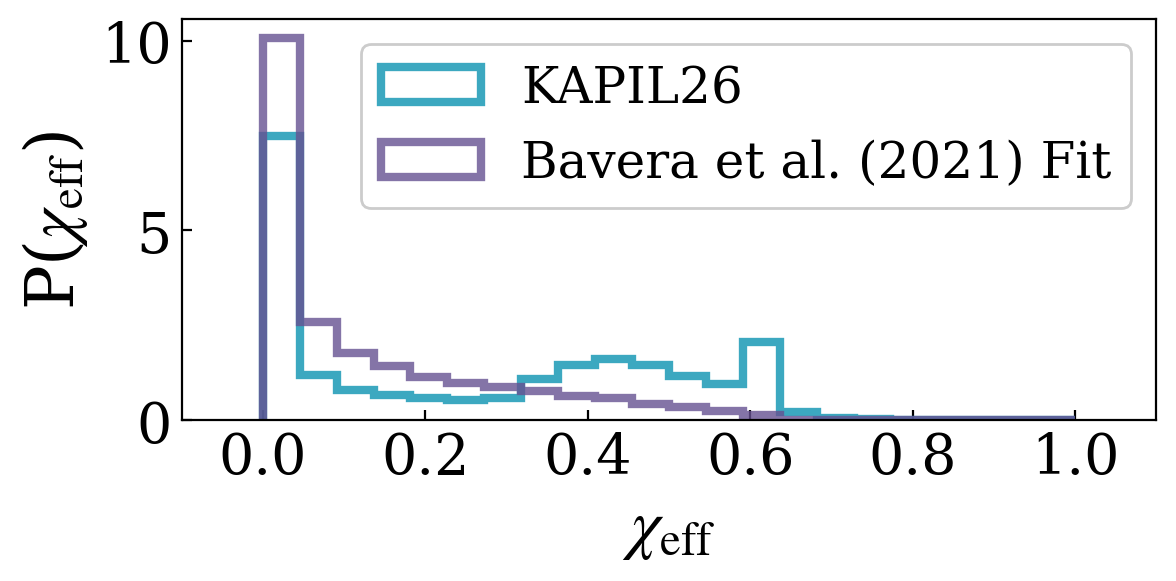

In [15]:
use_orbital_period = False

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6,3), sharey=False)

dco_type = 'BBH'

for pop_name in pop_names:
    pop_spin_df = pop_spin_dfs[pop_name]
    pop_spin_df = pop_spin_df[(pop_spin_df[dco_type]) & (pop_spin_df["Merges_Hubble_Time"])]

    chi_eff = pop_spin_df["chi_eff"]

    if use_orbital_period:
        chi_eff = pop_spin_df["chi_eff_orb"]
    
    if pop_name == 'notides' or 'bavera' in pop_name:
        chi_eff = pop_spin_df["chi_eff_orb"]
        

    #  # Label by primary and secondary of DCO
    # invert_mask = m1 < m2
    # a1_relabeled, a2_relabeled = a1.copy(), a2.copy()
    # a1_relabeled[invert_mask], a2_relabeled[invert_mask] = a2[invert_mask], a1[invert_mask]
    # a1, a2 = a1_relabeled, a2_relabeled

    bins = np.linspace(0, 1.0, 23)
    ax.hist(chi_eff, bins=bins, density=True, alpha=0.8, histtype='step', lw=3, ls='-', label=pop_labels[pop_name], color=pop_colors[pop_name])


# axes[0].set_title(dco_type, fontsize=20)
ax.set_xlabel('$\\chi_{\\rm eff}$', fontsize=24)
ax.set_ylabel('P($\\chi_{\\rm eff}$)', fontsize=24)

# axes[0].set_yscale('log')
# axes[0].legend(fontsize=20)


# axes[1].set_yscale('log')

ax.set_xlim(-0.1,1.1)

ax.tick_params(axis='both', direction='in', which='major', labelsize=20)

ax.set_xticks(ticks=np.linspace(0, 1, 6))

# axes[0].grid()
# axes[1].grid()

ax.legend(fontsize=18)
# axes[0].set_title(pop_labels[pop_name] + " with Bavera et al. (2021) Fit", fontsize=17)

plt.tight_layout()
plt.savefig(plot_path+'bavera_chi_eff_comparison_breakdown.pdf', dpi=300, bbox_inches='tight')

plt.show()

